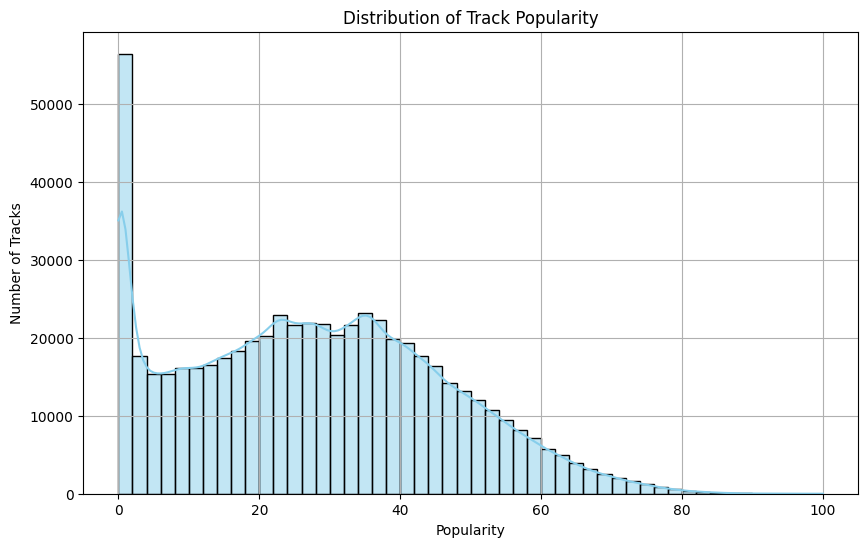

<ipython-input-1-44e1c7a3bb00>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='popularity', y='name', palette='viridis')


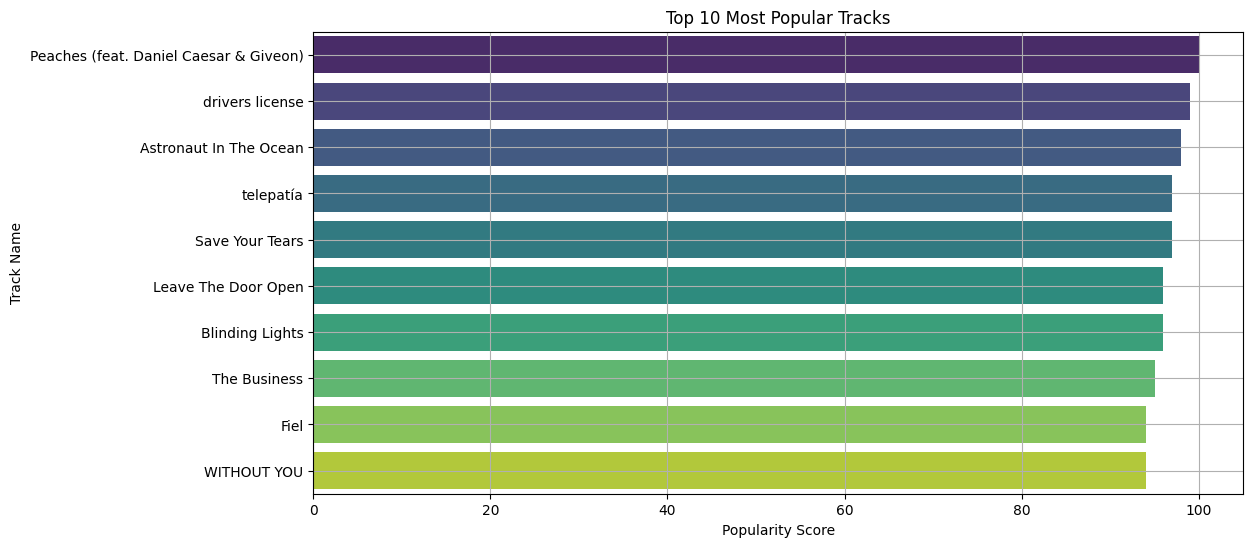

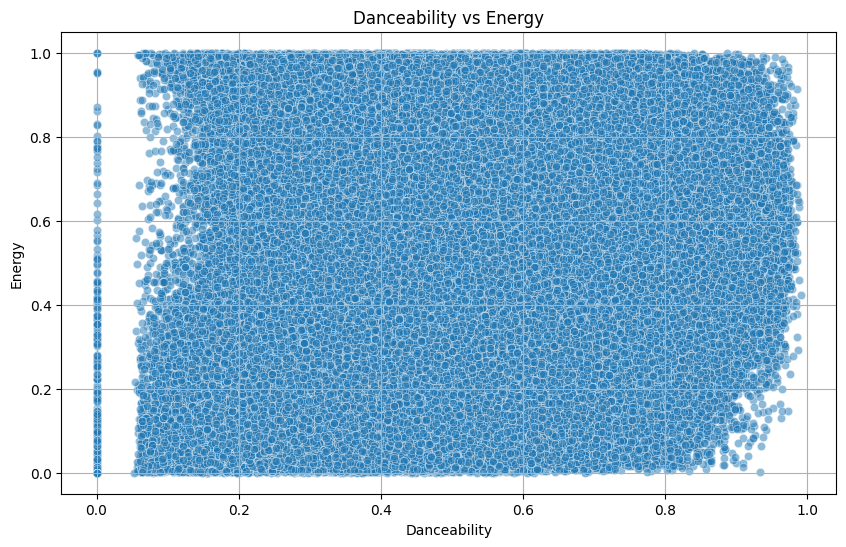

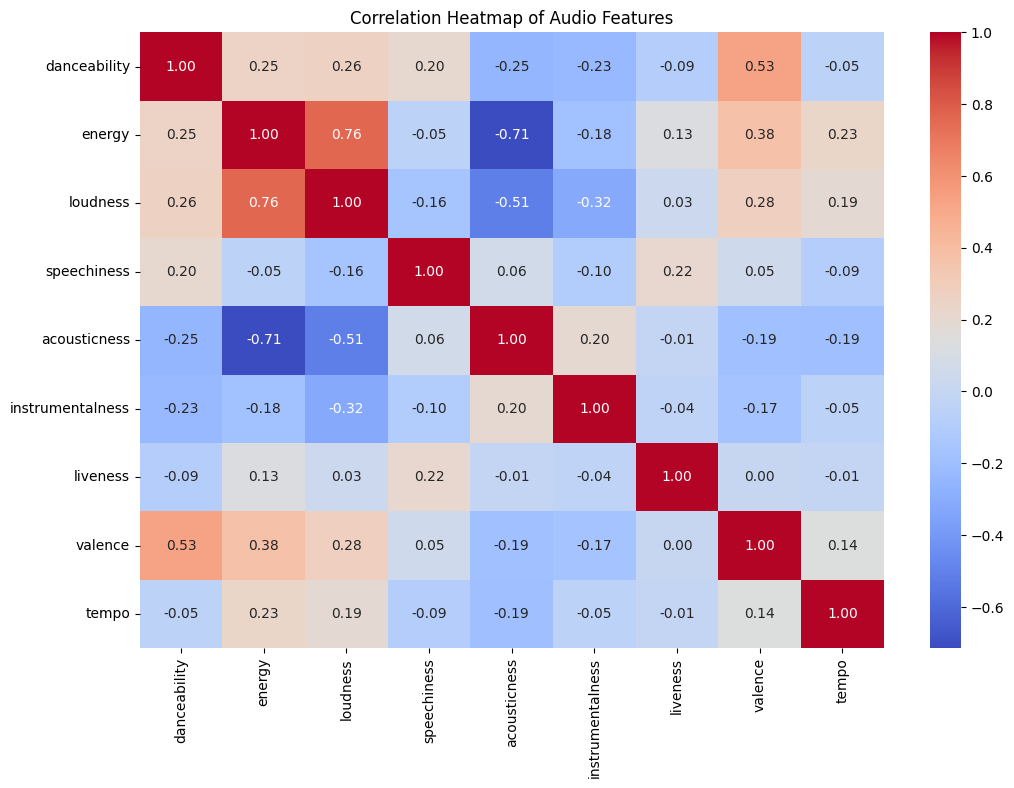

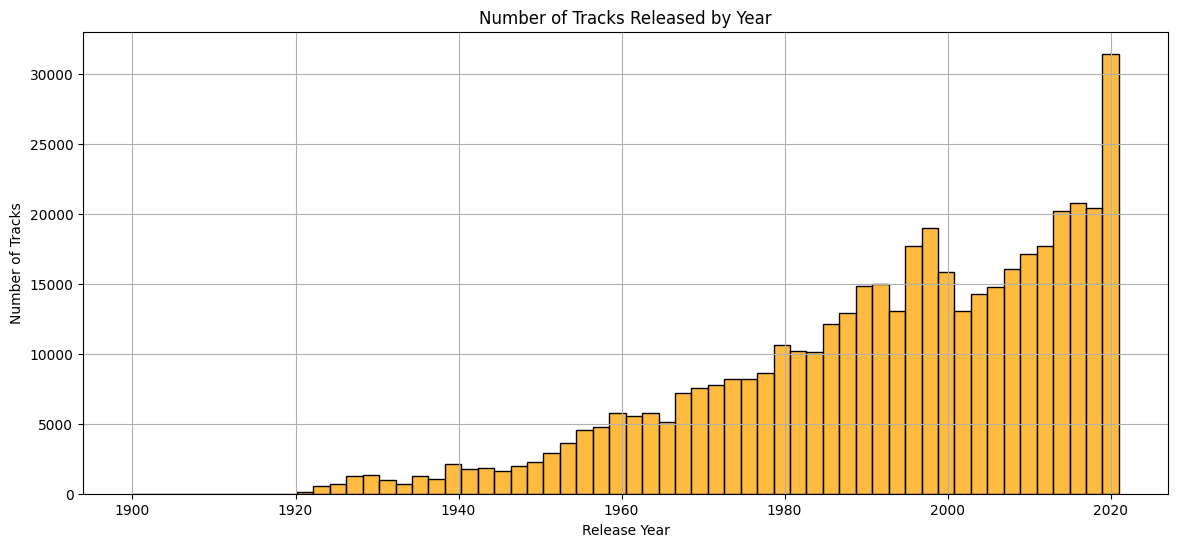

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('tracks.csv')

# Drop missing 'name' values
df = df.dropna(subset=['name'])

# 1. Popularity Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['popularity'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')
plt.grid(True)
plt.show()

# 2. Top 10 Most Popular Tracks
top_10 = df[['name', 'popularity']].sort_values(by='popularity', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top_10, x='popularity', y='name', palette='viridis')
plt.title('Top 10 Most Popular Tracks')
plt.xlabel('Popularity Score')
plt.ylabel('Track Name')
plt.grid(True)
plt.show()

# 3. Danceability vs Energy Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='danceability', y='energy', alpha=0.5)
plt.title('Danceability vs Energy')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.grid(True)
plt.show()

# 4. Correlation Heatmap
# Selecting relevant numerical features
numerical_features = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Taking a sample to avoid memory issues
df_sample = df[numerical_features].sample(20000, random_state=42)

plt.figure(figsize=(12,8))
corr = df_sample.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Audio Features')
plt.show()

# 5. Number of Tracks by Release Year
# First, ensure 'release_date' is datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract year
df['year'] = df['release_date'].dt.year

plt.figure(figsize=(14,6))
sns.histplot(df['year'].dropna(), bins=60, kde=False, color='orange')
plt.title('Number of Tracks Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Tracks')
plt.grid(True)
plt.show()


<ipython-input-2-08c68736778e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='explicit', palette='Set2')


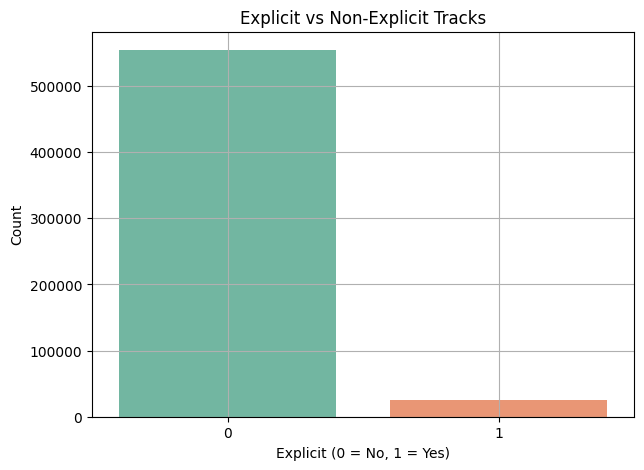

In [2]:
# Count of explicit vs non-explicit
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='explicit', palette='Set2')
plt.title('Explicit vs Non-Explicit Tracks')
plt.xlabel('Explicit (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.grid(True)
plt.show()


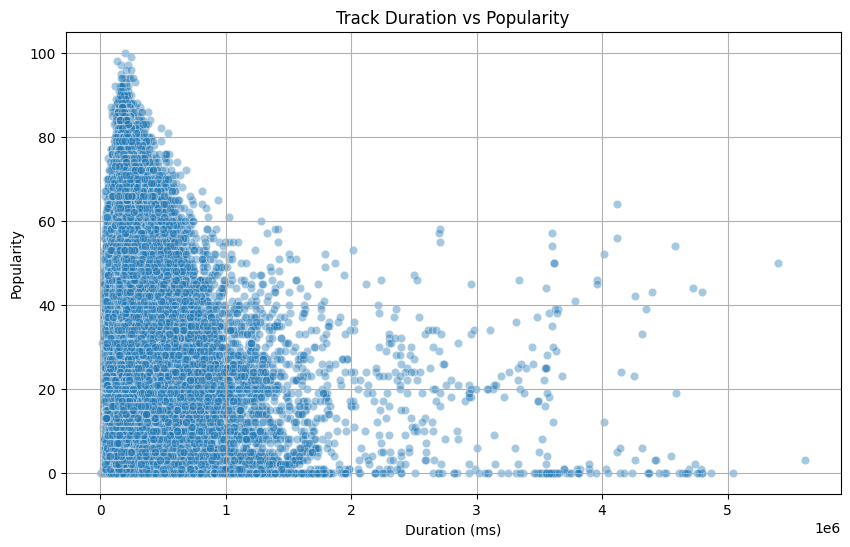

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='duration_ms', y='popularity', alpha=0.4)
plt.title('Track Duration vs Popularity')
plt.xlabel('Duration (ms)')
plt.ylabel('Popularity')
plt.grid(True)
plt.show()


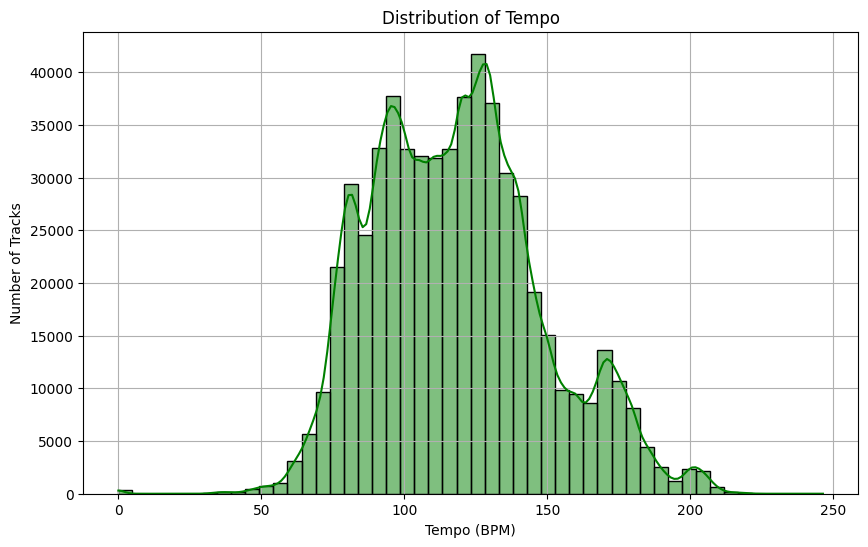

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['tempo'], bins=50, kde=True, color='green')
plt.title('Distribution of Tempo')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Number of Tracks')
plt.grid(True)
plt.show()


In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import ast

# 2. Load the dataset
df = pd.read_csv('tracks.csv')

# 3. Basic Preprocessing
# Drop missing names
df = df.dropna(subset=['name'])

# Convert 'artists' from string to list
df['artists'] = df['artists'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# 4. Select numerical features for recommendation
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[features]

# 5. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Train KNN Model
model_knn = NearestNeighbors(n_neighbors=6, algorithm='auto')
model_knn.fit(X_scaled)

# 7. Define Recommendation Function
def recommend_songs(song_name, n_recommendations=5):
    try:
        # Find the song in the dataset
        idx = df[df['name'].str.lower() == song_name.lower()].index[0]
        song_vector = X_scaled[idx].reshape(1, -1)

        # Get nearest neighbors
        distances, indices = model_knn.kneighbors(song_vector, n_neighbors=n_recommendations+1)

        # Skip the first one (itself)
        recommendations = df.iloc[indices[0][1:]][['name', 'artists', 'popularity']]
        return recommendations
    except IndexError:
        return "Song not found!"

# 8. Example Usage
recommended = recommend_songs('Carve')
print(recommended)


                      name                    artists  popularity
236583  Cruzados de Cristo  [Banda de la Recoleccion]          21
166676               Laulu            [Sielun Veljet]          13
23372   How Great Thou Art             [Trade Martin]           0
221332    השיר על ארץ סיני             [Shlomo Artzi]           6
446032       Vino I Gitare               [Gabi Novak]          23
